# Tech 4 Health (T4H)
Analysis of the electrophysiology profile at various depths after lowering the T4H motorized microdrive.

***Subject: RO1***


Notes:
Should LFP amplitude be normalized across sessions?


In [12]:
import numpy as np
import pandas as pd

import os
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import colormaps
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter
import seaborn as sns

from scipy.signal import ShortTimeFFT

sns.set_context('paper', font_scale=1.5)

In [3]:
DIR = r"\\research-cifs.nyumc.org\research\buzsakilab\Homes\voerom01\Tech4Health\T4H_R01" # data directory
OUT_DIR = r'r:\Tech4Health\Figures' # for saving figures
CHANNELS = [11, 14, 17, 18, 19, 22, 23, 25] # suriving channels after mishap

Building pandas dataframe to store session meta data

In [4]:
# getting the session files
session_files = [f for f in os.listdir(DIR) if f.startswith('T4H_R01_')]
print(f"Found {len(session_files)} session files.")

# getting the depths
depths_file = os.path.join(DIR, 'microdrive_depth.xlsx')
depths_df = pd.read_excel(depths_file, usecols=['Day', 'Time', 'Depth'])

for session in session_files:
    day = int(session.split('_')[2])
    time = session.split('_')[3]

    # append session name to the corresponding depth entry
    mask = (depths_df['Day'] == day) & (depths_df['Time'] == time)
    if not depths_df[mask].empty:
        depths_df.loc[mask, 'Session'] = session

# remove entry 6 (see microdrive_depths.xlsx for details)
depths_df = depths_df.drop(index=6).reset_index(drop=True)
print(depths_df)

Found 9 session files.
      Day Time  Depth            Session
0  251107   pm     60  T4H_R01_251107_pm
1  251108   am     60  T4H_R01_251108_am
2  251108   pm     60  T4H_R01_251108_pm
3  251109   am     60  T4H_R01_251109_am
4  251109   pm     60  T4H_R01_251109_pm
5  251110   am    120  T4H_R01_251110_am
6  251110   pm     60  T4H_R01_251110_pm
7  251111   am      0  T4H_R01_251111_am


## Finding examples of raw data
putitive stratum pyramidale: need to show a ripple and some spikes

Example session file: T4H_R01_251110_pm


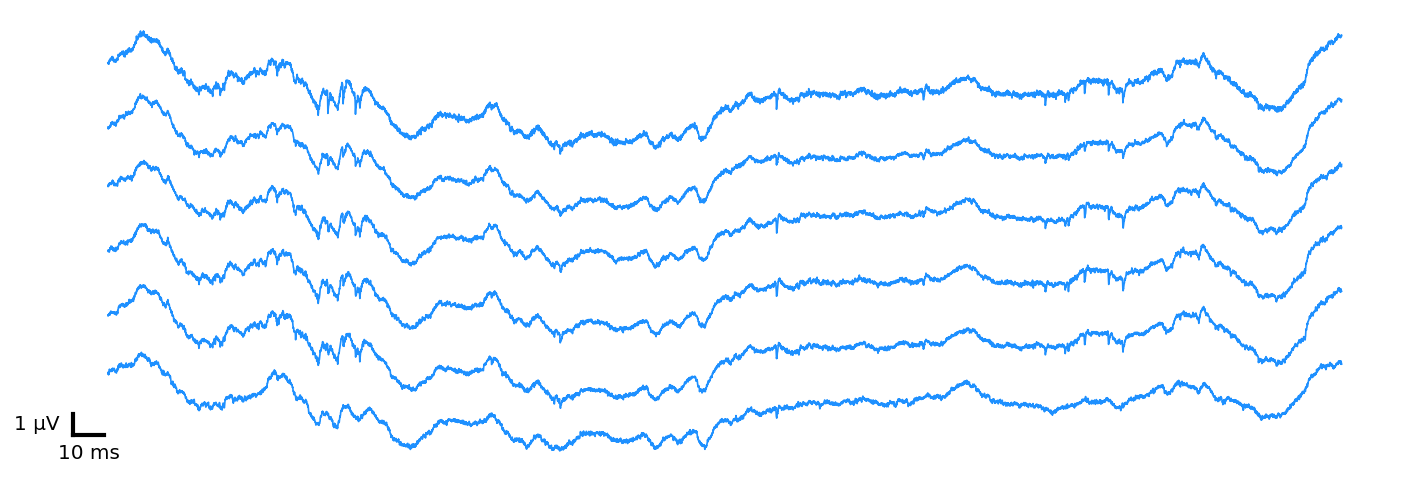

In [5]:
SESSION = 6
CHANNEL = 0
START = 1574.6 # seconds
STOP = 1575 # seconds
example_session = depths_df.iloc[SESSION]['Session']
dat_file = os.path.join(DIR, example_session,'amplifier.dat')
xml_file = os.path.join(DIR, example_session,'amplifier.xml')
print(f"Example session file: {example_session}")

# getting the nChannels and amplification from the XML file
tree = ET.parse(xml_file)
root = tree.getroot()
nChannels = int(root.find('acquisitionSystem').find('nChannels').text)
samplingRate = float(root.find('acquisitionSystem').find('samplingRate').text)
nBits = int(root.find('acquisitionSystem').find('nBits').text)
amplification = float(root.find('acquisitionSystem').find('amplification').text)
nSamples = os.path.getsize(dat_file) // (2 * nChannels)  # int16 = 2 bytes

# reading the binary file
data = np.memmap(dat_file, dtype='int16', mode='r', shape=(nSamples, nChannels))
channel_data = data[int(START * samplingRate):int(STOP * samplingRate), CHANNELS[1:7]] / amplification  # Convert to microvolts

fig, ax = plt.subplots(figsize=(18, 6))

for ch in range(channel_data.shape[1]):
    ax.plot(np.arange(len(channel_data)) / samplingRate,
            channel_data[:, ch] + ch * 3,
            color='dodgerblue')

# --- SCALE BAR PARAMETERS ---
scale_time = 0.01       
scale_amp  = 1        

# position anchor (in data coordinates)
x0 = ax.get_xlim()[0] + 0.02 * np.diff(ax.get_xlim())
y0 = ax.get_ylim()[0] + 0.08 * np.diff(ax.get_ylim())

# --- DRAW SCALE BAR ---
# time bar (horizontal)
ax.plot([x0, x0 + scale_time], [y0, y0], color='black', lw=3)
ax.text(x0 + scale_time/2, y0 - 0.02*np.diff(ax.get_ylim()),
        f'{scale_time*1000:.0f} ms', ha='center', va='top')

# amplitude bar (vertical)
ax.plot([x0, x0], [y0, y0 + scale_amp], color='black', lw=3)
ax.text(x0 - 0.01*np.diff(ax.get_xlim()), 
        y0 + scale_amp/2,
        f'{scale_amp:.0f} µV', ha='right', va='center')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_xticks([])
sns.despine(ax=ax, left=True, bottom=True)
plt.savefig(os.path.join(OUT_DIR, f'T4H_example_session_{example_session}_time_{START}_{STOP}.png'), dpi=300, bbox_inches='tight')
plt.show()


Putitive corpus callosum: 420 microns above str pyr

Example session file: T4H_R01_251107_pm


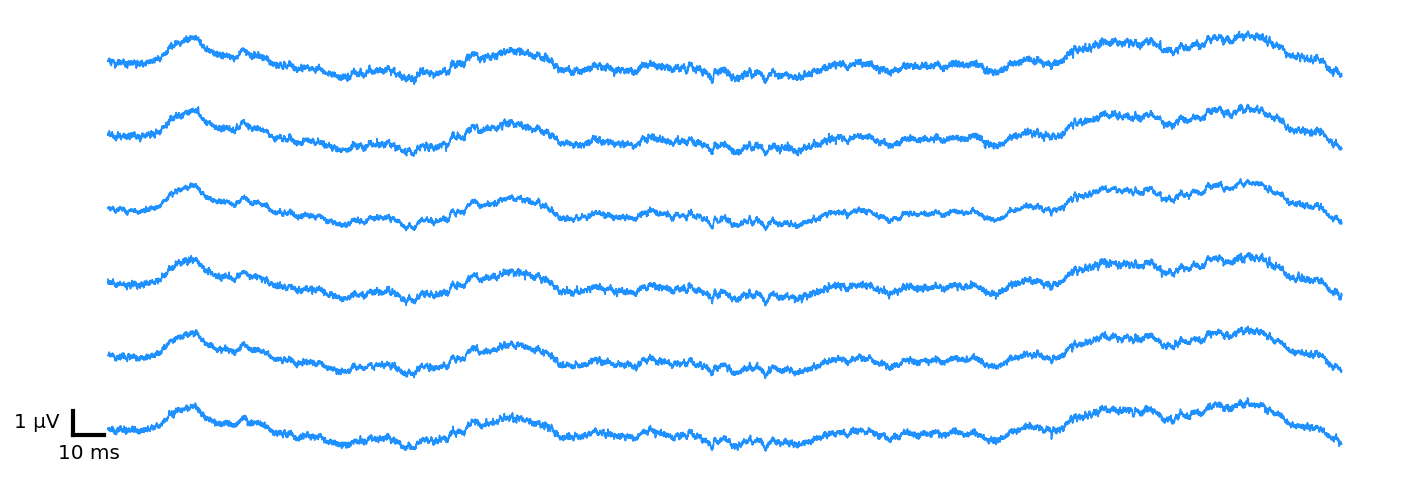

In [6]:
SESSION = 0
CHANNEL = 0
START = 1574.6 # seconds
STOP = 1575 # seconds
example_session = depths_df.iloc[SESSION]['Session']
dat_file = os.path.join(DIR, example_session,'amplifier.dat')
xml_file = os.path.join(DIR, example_session,'amplifier.xml')
print(f"Example session file: {example_session}")

# getting the nChannels and amplification from the XML file
tree = ET.parse(xml_file)
root = tree.getroot()
nChannels = int(root.find('acquisitionSystem').find('nChannels').text)
samplingRate = float(root.find('acquisitionSystem').find('samplingRate').text)
nBits = int(root.find('acquisitionSystem').find('nBits').text)
amplification = float(root.find('acquisitionSystem').find('amplification').text)
nSamples = os.path.getsize(dat_file) // (2 * nChannels)  # int16 = 2 bytes

# reading the binary file
data = np.memmap(dat_file, dtype='int16', mode='r', shape=(nSamples, nChannels))
channel_data = data[int(START * samplingRate):int(STOP * samplingRate), CHANNELS[1:7]] / amplification  # Convert to microvolts

fig, ax = plt.subplots(figsize=(18, 6))

for ch in range(channel_data.shape[1]):
    ax.plot(np.arange(len(channel_data)) / samplingRate,
            channel_data[:, ch] + ch * 3,
            color='dodgerblue')

# --- SCALE BAR PARAMETERS ---
scale_time = 0.01       
scale_amp  = 1        

# position anchor (in data coordinates)
x0 = ax.get_xlim()[0] + 0.02 * np.diff(ax.get_xlim())
y0 = ax.get_ylim()[0] + 0.08 * np.diff(ax.get_ylim())

# --- DRAW SCALE BAR ---
# time bar (horizontal)
ax.plot([x0, x0 + scale_time], [y0, y0], color='black', lw=3)
ax.text(x0 + scale_time/2, y0 - 0.02*np.diff(ax.get_ylim()),
        f'{scale_time*1000:.0f} ms', ha='center', va='top')

# amplitude bar (vertical)
ax.plot([x0, x0], [y0, y0 + scale_amp], color='black', lw=3)
ax.text(x0 - 0.01*np.diff(ax.get_xlim()), 
        y0 + scale_amp/2,
        f'{scale_amp:.0f} µV', ha='right', va='center')

ax.set_xlabel('')
ax.set_ylabel('')
ax.set_yticks([])
ax.set_xticks([])
# remove all spines
sns.despine(ax=ax, left=True, bottom=True)
#plt.savefig(os.path.join(OUT_DIR, f'T4H_example_session_{example_session}_time_{START}_{STOP}.png'), dpi=300, bbox_inches='tight')
plt.show()


## Estimating multi unit activity power

T4H_R01_251107_pm
session: T4H_R01_251107_pm
T4H_R01_251108_am
session: T4H_R01_251108_am
T4H_R01_251108_pm
session: T4H_R01_251108_pm
T4H_R01_251109_am
session: T4H_R01_251109_am
T4H_R01_251109_pm
session: T4H_R01_251109_pm
T4H_R01_251110_am
session: T4H_R01_251110_am
T4H_R01_251110_pm
session: T4H_R01_251110_pm
T4H_R01_251111_am
session: T4H_R01_251111_am


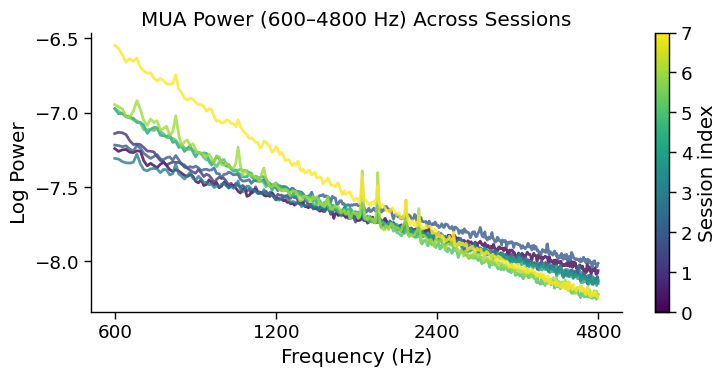

In [ ]:
# computing the MUA power across sessions
START = 100  # seconds
STOP  =  1300 # seconds
FRANGE = (600, 4800)  # Hz

powers = []
depth = 0
depths = []

n_sessions = len(depths_df)

cmap = colormaps.get_cmap('viridis')
colors = [cmap(i / (n_sessions - 1)) for i in range(n_sessions)]


for session in depths_df.index:
    example_session = depths_df.iloc[session]['Session']

    print(example_session)
    dat_file = os.path.join(DIR, example_session, 'amplifier.dat')
    xml_file = os.path.join(DIR, example_session, 'amplifier.xml')

    if not os.path.exists(dat_file) or not os.path.exists(xml_file):
        dat_file = os.path.join(DIR, example_session,f'{example_session}.dat')
        xml_file = os.path.join(DIR, example_session,f'{example_session}.xml')
    print(f"session: {example_session}")

    depths.append(depth)
    depth -= int(depths_df.iloc[session]['Depth'])


    # ----- load recording metadata -----
    tree = ET.parse(xml_file)
    root = tree.getroot()
    acq = root.find('acquisitionSystem')
    nChannels     = int(acq.find('nChannels').text)
    samplingRate  = float(acq.find('samplingRate').text)
    nBits         = int(acq.find('nBits').text)
    amplification = float(acq.find('amplification').text)

    nSamples = os.path.getsize(dat_file) // (2 * nChannels)  # int16 = 2 bytes

    # ----- build window for welch's method -----
    win_len = int(samplingRate * 0.1)   # 100ms
    WINDOW = np.hanning(win_len)
    hop = win_len # no overlap; use e.g. win_len // 2 if you want 50% overlap


    # ----- read data (memmap) and select channels -----
    data = np.memmap(dat_file, dtype='int16', mode='r',
                     shape=(nSamples, nChannels))

    # time slice [START, STOP] for selected channels
    t_start = int(START * samplingRate)
    t_stop  = int(STOP  * samplingRate)

    # channel_data: (T, n_selected_channels)
    channel_data = data[t_start:t_stop, CHANNELS[:]] / amplification  # µV


    # ----- compute STFT / PSD -----
    SFT = ShortTimeFFT(WINDOW, fs=samplingRate,
                       scale_to='psd', hop=hop)
    Sxs = []
    # looping over channels
    for ch in range(channel_data.shape[1]):
        mua = channel_data[:, ch] 
    
        # Sx: shape (n_freqs, n_time_windows)
        Sx = np.abs(SFT.stft(mua))
        Sxs.append(Sx)

    Sx = np.mean(np.array(Sxs), axis=(0)) # average across channels


    # ----- get frequency axes -----
    freqs = SFT.f         
            

    ind = np.where((freqs >= FRANGE[0]) & (freqs <= FRANGE[1]))[0]
    freqs = freqs[ind]
    Sx = Sx[ind, :]

    mean_power = np.mean(Sx, axis = 1)
    powers.append(np.log(mean_power))


    # --- plotting ---
    if session == depths_df.index[0]:
        # Initialize the multi-session figure once
        fig_all, ax_all = plt.subplots(figsize=(8, 4))
        
    # plot on the shared axes
    color = colors[session]
    ax_all.plot(freqs, np.log(mean_power), color=color, alpha=0.8, linewidth=2)



# Format shared plot
ax_all.set_xscale('log')
ax_all.set_ylim()
ax_all.set_xlabel('Frequency (Hz)')
ax_all.set_ylabel('Log Power')
ax_all.set_title('MUA Power (600–4800 Hz) Across Sessions')

# 1. Fix major tick positions and labels
ticks = [600, 1200, 2400, 4800]
tick_labels = ['600', '1200', '2400', '4800']
ax_all.xaxis.set_major_locator(FixedLocator(ticks))
ax_all.xaxis.set_major_formatter(FixedFormatter(tick_labels))

# 2. Turn off minor tick labels (and optionally minor ticks entirely)
ax_all.xaxis.set_minor_formatter(NullFormatter())
ax_all.tick_params(axis='x', which='minor', bottom=False)

# 3. Hide the little "×10^3" style offset text, if present
ax_all.get_xaxis().get_offset_text().set_visible(False)

# create mappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=n_sessions-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for older Matplotlib versions

cbar = fig_all.colorbar(sm, ax=ax_all)
cbar.set_label("Session index")

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'power_spectrum_window_{win_len / samplingRate}_ frange_{FRANGE}_duration_{STOP - START}s.png'), dpi=300)
plt.show()




# plot mean powers across sessions
powers = np.array(powers)
depths = np.array(depths)

sort_idx = np.argsort(depths)
depths = np.array(depths)[sort_idx]
powers = np.array(powers)[sort_idx]



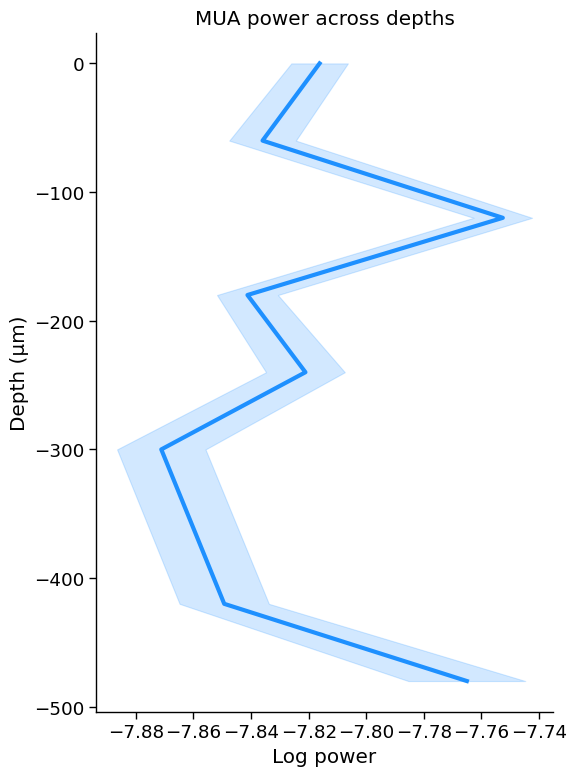

In [16]:
fig, ax = plt.subplots(figsize=(6, 8))

# Compute summary statistics
mean_power = np.mean(powers, axis=1)
sem_power  = np.std(powers, axis=1) / np.sqrt(powers.shape[1])  # SEM

# Sort by depth if needed
# (sns.lineplot with sort=False keeps original order,
# but for fill_between you usually want monotonic x)
order = np.argsort(depths)
depths_sorted     = depths[order]
mean_sorted       = mean_power[order]
sem_sorted        = sem_power[order]

# Plot mean line
ax.plot(mean_sorted, depths_sorted, color='dodgerblue', linewidth=3)

# Shaded error bars (mean ± std)
ax.fill_betweenx(
    depths_sorted,
    mean_sorted - sem_sorted,
    mean_sorted + sem_sorted,
    color='dodgerblue',
    alpha=0.2
)

# Labels + aesthetics
ax.set_ylabel('Depth (µm)')
ax.set_xlabel('Log power')
ax.set_title('MUA power across depths')
sns.despine()
plt.tight_layout()

plt.savefig(os.path.join(
    OUT_DIR,
    f'mua_power_vs_depth_window_length_{win_len / samplingRate}_frange_{FRANGE}_duration_{STOP - START}s.png'
), dpi=300)

plt.show()


## Estimating ripple power

session: T4H_R01_251107_pm
session: T4H_R01_251108_am
session: T4H_R01_251108_pm
session: T4H_R01_251109_am
session: T4H_R01_251109_pm
session: T4H_R01_251110_am
session: T4H_R01_251110_pm
session: T4H_R01_251111_am


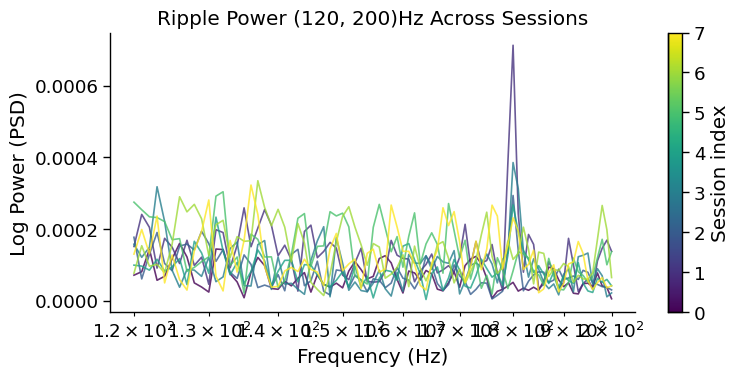

In [39]:
# computing the ripple power across sessions
START = 300  # seconds
STOP  = 1500  # seconds
FRANGE = (120, 200)  # Hz

powers = []
depth = 0
depths = []

n_sessions = len(depths_df)

cmap = colormaps.get_cmap('viridis')
colors = [cmap(i / (n_sessions - 1)) for i in range(n_sessions)]


for session in depths_df.index:
    example_session = depths_df.iloc[session]['Session']
    dat_file = os.path.join(DIR, example_session, 'amplifier.dat')
    xml_file = os.path.join(DIR, example_session, 'amplifier.xml')
    print(f"session: {example_session}")

    depths.append(depth)
    depth -= int(depths_df.iloc[session]['Depth'])


    # ----- load recording metadata -----
    tree = ET.parse(xml_file)
    root = tree.getroot()
    acq = root.find('acquisitionSystem')
    nChannels     = int(acq.find('nChannels').text)
    samplingRate  = float(acq.find('samplingRate').text)
    nBits         = int(acq.find('nBits').text)
    amplification = float(acq.find('amplification').text)

    nSamples = os.path.getsize(dat_file) // (2 * nChannels)  # int16 = 2 bytes

    # ----- build window for welch's method -----
    win_len = int(samplingRate * 1)   # 1000ms
    WINDOW = np.hanning(win_len)
    hop = win_len  # no overlap; use e.g. win_len // 2 if you want 50% overlap


    # ----- read data (memmap) and select channels -----
    data = np.memmap(dat_file, dtype='int16', mode='r',
                     shape=(nSamples, nChannels))

    # time slice [START, STOP] for selected channels
    t_start = int(START * samplingRate)
    t_stop  = int(STOP  * samplingRate)

    # channel_data: (T, n_selected_channels)
    channel_data = data[t_start:t_stop, CHANNELS[:]] / amplification  # µV


    # ----- compute STFT / PSD -----
    SFT = ShortTimeFFT(WINDOW, fs=samplingRate,
                       scale_to='psd', hop=hop)
    Sxs = []
    # looping over channels
    for ch in range(channel_data.shape[1]):
        mua = channel_data[:, ch] 
    
        # Sx: shape (n_freqs, n_time_windows)
        Sx = SFT.stft(mua)
        Sxs.append(Sx)

    Sx = np.mean(np.array(Sxs), axis=(0,2)) # average across channels and time

    # ----- get frequency axes -----
    freqs = SFT.f                          # (n_freqs,)

    ind = np.where((freqs >= FRANGE[0]) & (freqs <= FRANGE[1]))[0]
    freqs = freqs[ind]
    Sx = Sx[ind]

    mean_power = np.mean(np.abs(Sx))
    powers.append(np.log(mean_power))


    # --- plotting ---
    if session == depths_df.index[0]:
        # Initialize the multi-session figure once
        fig_all, ax_all = plt.subplots(figsize=(8, 4))
        
    # plot on the shared axes
    color = colors[session]
    ax_all.plot(freqs, np.abs(Sx), color=color, alpha=0.8)



# Format shared plot
ax_all.set_xscale('log')
ax_all.set_ylim()   
ax_all.set_xlabel('Frequency (Hz)')
ax_all.set_ylabel('Log Power (PSD)')
ax_all.set_title(f'Ripple Power {FRANGE}Hz Across Sessions')

# create mappable for the colorbar
norm = mcolors.Normalize(vmin=0, vmax=n_sessions-1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # required for older Matplotlib versions

cbar = fig_all.colorbar(sm, ax=ax_all)
cbar.set_label("Session index")

sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'ripple_power_spectrum_window_{win_len / samplingRate}_ frange_{FRANGE}_duration_{STOP - START}s.png'), dpi=300)
plt.show()




# plot mean powers across sessions
powers = np.array(powers)
depths = np.array(depths)

sort_idx = np.argsort(depths)
depths = np.array(depths)[sort_idx]
powers = np.array(powers)[sort_idx]



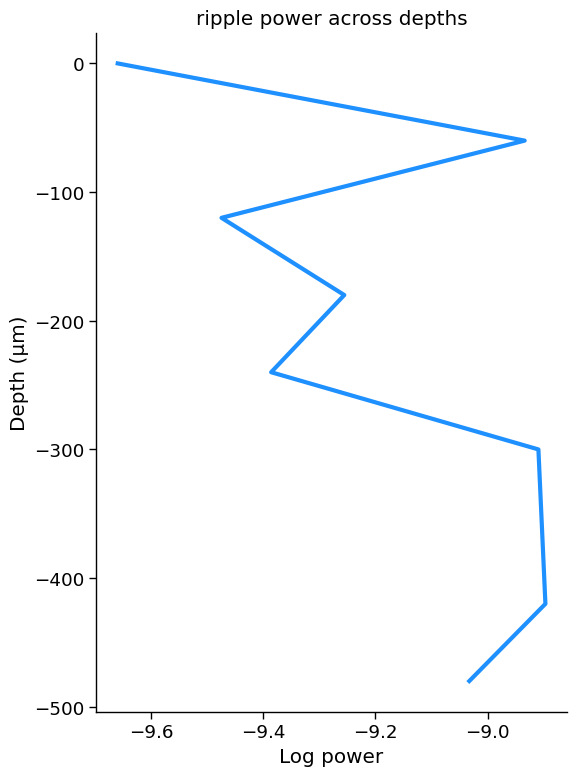

In [40]:
sort_idx = np.argsort(depths)
depths = np.array(depths)[sort_idx]
powers = np.array(powers)[sort_idx]

fig, ax = plt.subplots(figsize=(6, 8))
sns.lineplot(x=powers, y=depths, ax=ax, linewidth=3, color='dodgerblue', sort=False)
ax.set_ylabel('Depth (µm)')
ax.set_xlabel('Log power')
ax.set_title('ripple power across depths')
sns.despine()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, f'ripple_power_vs_depth_window_length_{win_len / samplingRate}_frange_{FRANGE}_duration_{STOP - START}s.png'), dpi=300)
plt.show()